In [3]:
pip install -U finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00


In [ ]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
def get_close(ticker, start, end=None):
    """
    종가 데이터 수집
    """
    return fdr.DataReader(ticker, start, end)['Close']

In [10]:
kodex200 = get_close("069500", "2024")
kodex200

,Close
Date,
2024-01-02,34802
2024-01-03,33837
2024-01-04,33540
2024-01-05,33445
2024-01-08,33335
...,...
2026-01-05,65040
2026-01-06,66210
2026-01-07,66720


In [11]:
def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

In [12]:
calc_daily_return(kodex200)

,Close
Date,
2024-01-02,0.000000
2024-01-03,-0.027728
2024-01-04,-0.008777
2024-01-05,-0.002832
2024-01-08,-0.003289
...,...
2026-01-05,0.037983
2026-01-06,0.017989
2026-01-07,0.007703


In [13]:
def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

In [14]:
calc_cum_return(kodex200)

,Close
Date,
2024-01-02,1.000000
2024-01-03,0.972272
2024-01-04,0.963738
2024-01-05,0.961008
2024-01-08,0.957847
...,...
2026-01-05,1.868858
2026-01-06,1.902477
2026-01-07,1.917131


In [15]:
def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret

In [16]:
kodex10Bond = get_close("152380", "2024")

In [17]:
prices = pd.concat([kodex200, kodex10Bond], axis=1)
prices.columns = ['kodex200', 'kodex10Bond']
prices

,kodex200,kodex10Bond
Date,,
2024-01-02,34802,65291
2024-01-03,33837,65158
2024-01-04,33540,65445
2024-01-05,33445,65009
2024-01-08,33335,65069
...,...,...
2026-01-05,65040,67560
2026-01-06,66210,67560
2026-01-07,66720,67850


In [18]:
calc_portfolio(prices)

(Date
 2024-01-02    0.000000
 2024-01-03   -0.014883
 2024-01-04   -0.002100
 2024-01-05   -0.004785
 2024-01-08   -0.001146
                 ...   
 2026-01-05    0.023236
 2026-01-06    0.011578
 2026-01-07    0.006501
 2026-01-08    0.000038
 2026-01-09   -0.008986
 Length: 492, dtype: float64,
 Date
 2024-01-02    1.000000
 2024-01-03    0.985117
 2024-01-04    0.983048
 2024-01-05    0.978344
 2024-01-08    0.977224
                 ...   
 2026-01-05    1.451805
 2026-01-06    1.468614
 2026-01-07    1.478162
 2026-01-08    1.478219
 2026-01-09    1.464936
 Length: 492, dtype: float64)

In [19]:
def evaluate_performance(cum_ret, daily_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성
    #위험은 시간의 제곱근에 비례

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

In [20]:
daily_ret, cum_ret =calc_portfolio(prices)

In [21]:
evaluate_performance(cum_ret, daily_ret);

▶ 최종 수익률   : 46.49%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 21.60%
2. 안정성 (MDD)  : -9.38%
------------------------------
3. 연간 변동성   : 11.66%
4. 샤프 지수     : 1.5648


/tmp/ipython-input-1128184836.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


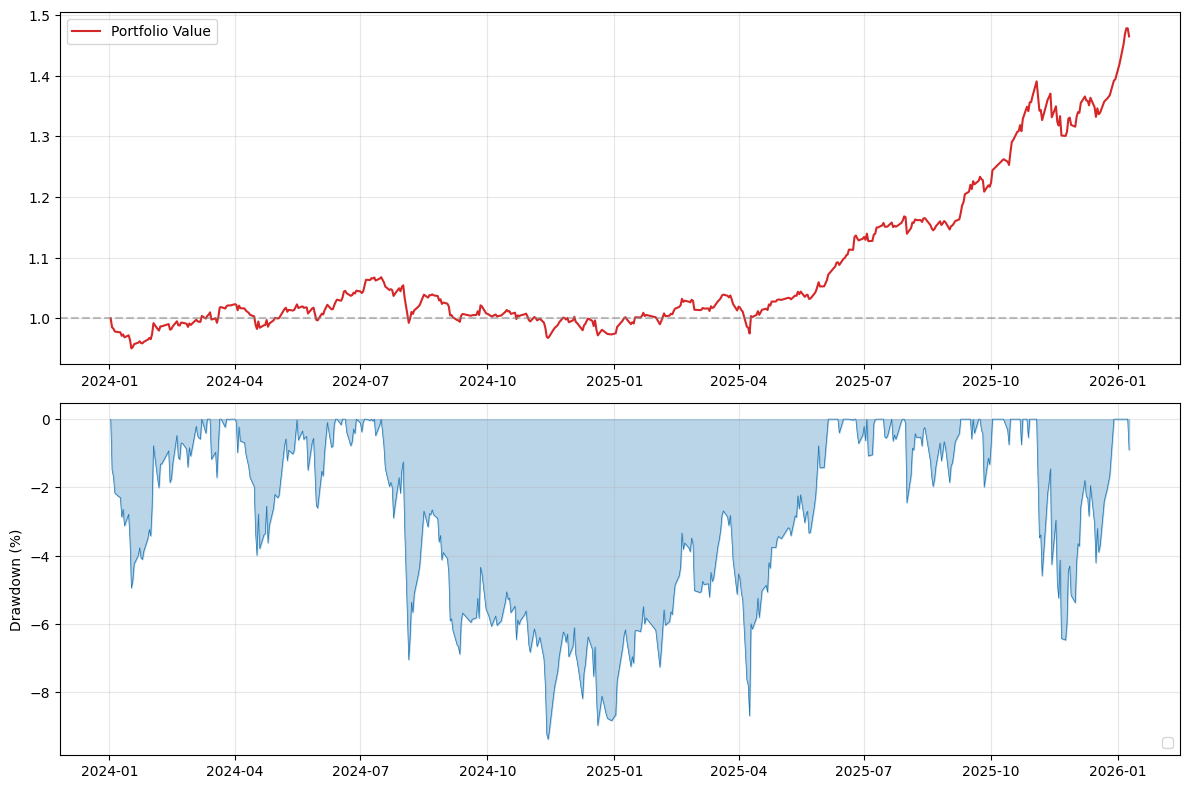

In [22]:
#시각화
historical_max = cum_ret.cummax()
dd = (cum_ret - historical_max) / historical_max * 100
mdd = dd.min()

plt.figure(figsize=(12, 8))

# [차트 1] 누적 수익률 (Asset Growth)
plt.subplot(2, 1, 1)
plt.plot(cum_ret.index, cum_ret, label='Portfolio Value', color='#d62728') # Red
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5) # 본전 라인
plt.legend()
plt.grid(True, alpha=0.3)

# [차트 2] 낙폭 (Drawdown)
plt.subplot(2, 1, 2)
plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3) # Blue shading
plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylabel('Drawdown (%)')

plt.tight_layout()
plt.show()

In [23]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolo(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance( daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

In [25]:

kodex200 = get_close("069500", "2024")
kodex10Bond = get_close("152380", "2024")
prices = pd.concat([kodex200, kodex10Bond], axis=1)

day_ret , cum_ret =calc_portfolio(prices, [0.7, 0.3])
_ = evaluate_performance(daily_ret, cum_ret)


▶ 최종 수익률   : 63.78%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 28.75%
2. 안정성 (MDD)  : -13.97%
------------------------------
3. 연간 변동성   : 11.66%
4. 샤프 지수     : 1.5648


포트폴리오 분석 함수(실습)

데이터 입력:
tickers: 종목 코드 리스트 (예: ['005930', '000660'])
weights: 투자 비중 리스트 (예: [0.6, 0.4]) -> 합이 1이어야 함

수학적 계산: CAGR, MDD, 샤프 지수, 변동성을 자동으로 계산합니다.

시각화 리포트: 상단에는 '수익률 곡선', 하단에는 'Drawdown'을 그려서 시각적으로 분석합니다.
```

